In [98]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import struct


In [99]:
#data to tensor script (from claude)
def load_idx_images(path):
    with open(path, 'rb') as f:
        magic, num_images, rows, cols = struct.unpack('>IIII', f.read(16))
        image_data = np.frombuffer(f.read(), dtype=np.uint8)
        images = image_data.reshape(num_images, rows, cols)
    return images

def load_idx_labels(path):
    with open(path, 'rb') as f:
        magic, num_labels = struct.unpack('>II', f.read(8))
        label_data = np.frombuffer(f.read(), dtype=np.uint8)
    return label_data

In [100]:
#data load to tensor
images = load_idx_images('../data/MNIST_DATA/train-images.idx3-ubyte')
labels = load_idx_labels('../data/MNIST_DATA/train-labels.idx1-ubyte')
test_images = load_idx_images('../data/MNIST_DATA/t10k-images.idx3-ubyte')
test_labels = load_idx_labels('../data/MNIST_DATA/t10k-labels.idx1-ubyte')

images_normalized = images.astype(np.float32) / 255.0
test_images_normalized = test_images.astype(np.float32) / 255.0


images_tensor = torch.from_numpy(images_normalized)
labels_tensor = torch.from_numpy(labels.astype(np.int64))

test_images_tensor = torch.from_numpy(test_images_normalized)
test_labels_tensor = torch.from_numpy(test_labels.astype(np.int64))

In [101]:
print(images_tensor.shape)
print(labels_tensor.shape)

print(test_images_tensor.shape)
print(test_labels_tensor.shape)

torch.Size([60000, 28, 28])
torch.Size([60000])
torch.Size([10000, 28, 28])
torch.Size([10000])


In [102]:
#pytorch dataset
class CTDataset(Dataset):
    def __init__(self, image_tensor, label_tensor):
        self.x = image_tensor.float()
        self.y = label_tensor
    def __len__(self):
        return self.x.shape[0]
    def __getitem__(self, ix):
        return self.x[ix], self.y[ix]

In [103]:
train_ds = CTDataset(images_tensor, labels_tensor)
train_dl = DataLoader(train_ds, batch_size=5)

test_ds = CTDataset(test_images_tensor, test_labels_tensor)
test_dl = DataLoader(test_ds, batch_size=5)

L = nn.CrossEntropyLoss()

In [104]:
#network
class MyNeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.Matrix1 = nn.Linear(28**2,100)
        self.Matrix2 = nn.Linear(100,50)
        self.Matrix3 = nn.Linear(50,10)
        self.R = nn.ReLU()
    def forward(self,x):
        x = x.view(-1,28**2)
        x = self.R(self.Matrix1(x))
        x = self.R(self.Matrix2(x))
        x = self.Matrix3(x)
        return x

In [105]:
f = MyNeuralNet()
from torch.optim import SGD

In [106]:
#training function
def train_model(dl, f, n_epochs=20):
    opt = SGD(f.parameters(), lr=0.01)
    L = nn.CrossEntropyLoss()

    losses = []
    epochs = []
    for epoch in range(n_epochs):
        print(f'Epoch {epoch}')
        N = len(dl)
        for i, (x, y) in enumerate(dl):
            opt.zero_grad()
            loss_value = L(f(x), y)
            loss_value.backward()
            opt.step()
            epochs.append(epoch+i/N)
            losses.append(loss_value.item())
    return np.array(epochs), np.array(losses)

In [107]:
#training loop
epoch_data, loss_data = train_model(train_dl, f)

Epoch 0
Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15
Epoch 16
Epoch 17
Epoch 18
Epoch 19


Text(0.5, 1.0, 'Cross Entrophy per Batch')

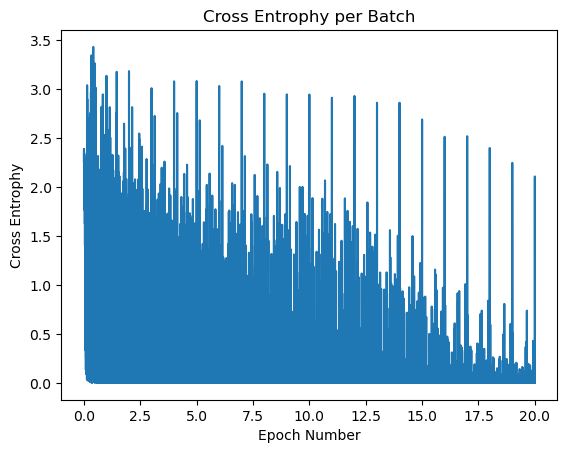

In [108]:
plt.plot(epoch_data, loss_data)
plt.xlabel('Epoch Number')
plt.ylabel('Cross Entrophy')
plt.title('Cross Entrophy per Batch')

Text(0.5, 1.0, 'Cross Entrophy per Batch')

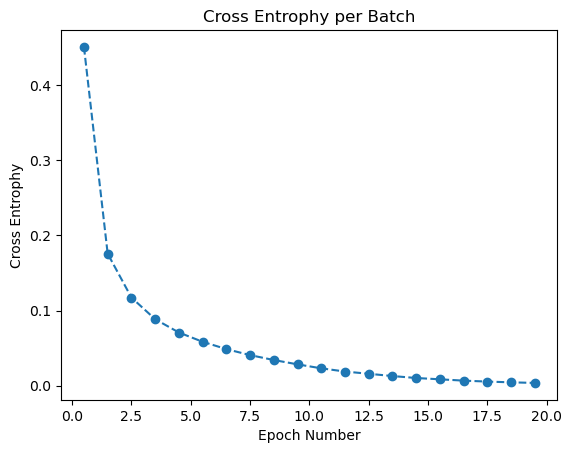

In [109]:
epoch_data_avg = epoch_data.reshape(20,-1).mean(axis=1)
loss_data_avg = loss_data.reshape(20,-1).mean(axis=1)

plt.plot(epoch_data_avg, loss_data_avg, 'o--')
plt.xlabel('Epoch Number')
plt.ylabel('Cross Entrophy')
plt.title('Cross Entrophy per Batch')

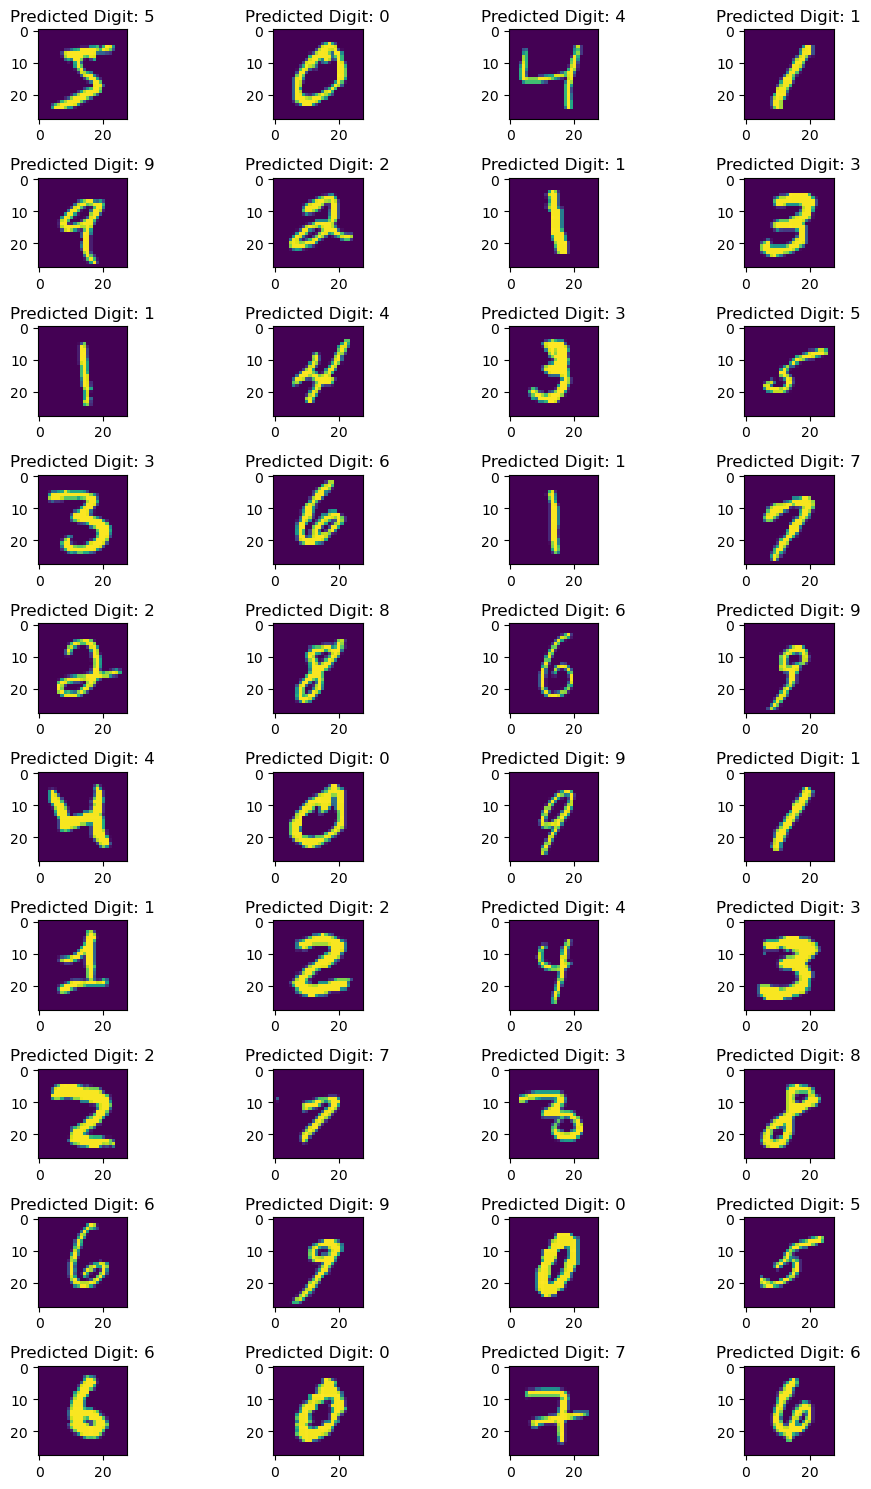

In [110]:
xs, ys = train_ds[0:2000]
yhats = f(xs).argmax(axis=1)

fig, ax = plt.subplots(10,4,figsize=(10,15))
for i in range(40):
    plt.subplot(10,4,i+1)
    plt.imshow(xs[i])
    plt.title(f'Predicted Digit: {yhats[i]}')
fig.tight_layout()
plt.show()

In [111]:
#test set
f.eval()
with torch.no_grad():
    xs, ys = test_ds[:2000]
    yhats = f(xs).argmax(axis=1)

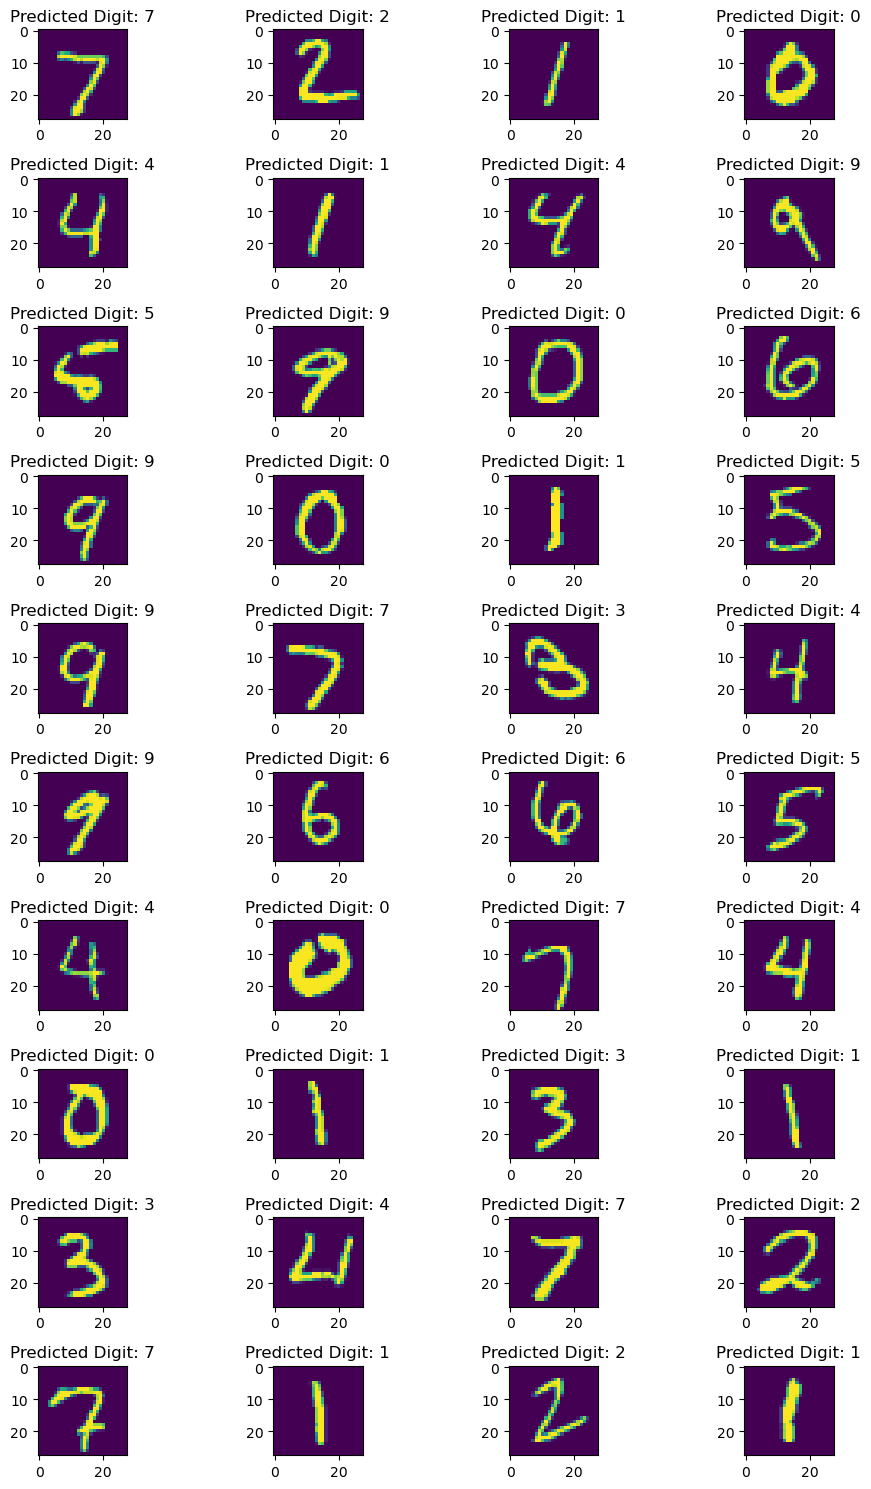

In [112]:
fig, ax = plt.subplots(10,4,figsize=(10,15))
for i in range(40):
    plt.subplot(10,4,i+1)
    plt.imshow(xs[i])
    plt.title(f'Predicted Digit: {yhats[i]}')
fig.tight_layout()
plt.show()

In [ ]:
#model performance metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

yhats_np = yhats.numpy()
ys_np = ys.numpy()

print(accuracy_score(ys_np, yhats_np))
print(confusion_matrix(ys_np, yhats_np))
print(classification_report(ys_np, yhats_np))

0.9735
[[174   0   0   0   0   0   1   0   0   0]
 [  0 232   1   0   1   0   0   0   0   0]
 [  1   1 215   0   0   0   1   1   0   0]
 [  0   0   0 203   0   1   0   2   0   1]
 [  0   0   1   0 213   1   1   0   0   1]
 [  0   0   0   2   1 175   0   0   1   0]
 [  2   0   2   0   0   3 171   0   0   0]
 [  0   1   5   1   0   0   0 193   0   5]
 [  1   0   3   2   1   0   0   1 183   1]
 [  0   0   0   2   2   2   0   0   0 188]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       175
           1       0.99      0.99      0.99       234
           2       0.95      0.98      0.96       219
           3       0.97      0.98      0.97       207
           4       0.98      0.98      0.98       217
           5       0.96      0.98      0.97       179
           6       0.98      0.96      0.97       178
           7       0.98      0.94      0.96       205
           8       0.99      0.95      0.97       192
           9       0.